In [20]:
from json import load
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
## load the data
def load_hw1_problem1_data(data_path):
    data_path = Path(data_path)
    df = pd.read_csv(data_path)
    x = df["X"].to_numpy(dtype=float)
    y = df["Y"].to_numpy(dtype=float)
    return x, y, df

def generate_hw1_problem1_synth(
    n=200,
    theta1_true=1.5,
    theta2_true=2.0,
    noise_std=0.2,
    seed=123,
):
    np.random.seed(seed)
    x = np.random.uniform(0, 10, n)
    y_true = model_fn(x, theta1_true, theta2_true)
    noise = np.random.normal(0, noise_std, n)
    y = y_true + noise
    
    return x, y
    
    pass
## process function
def model_fn(x, theta1, theta2):
    out = theta1*(np.sin(x) + np.cos(theta2 * x))
    return out

## loss function
def square_error_loss(y_true, y_pred):
    return sum((y_pred - y_true)**2)



In [32]:
## load in the data
x, y, df = load_hw1_problem1_data('../dataset/homework/HW1_Problem1_Data.csv')

## Problem 1

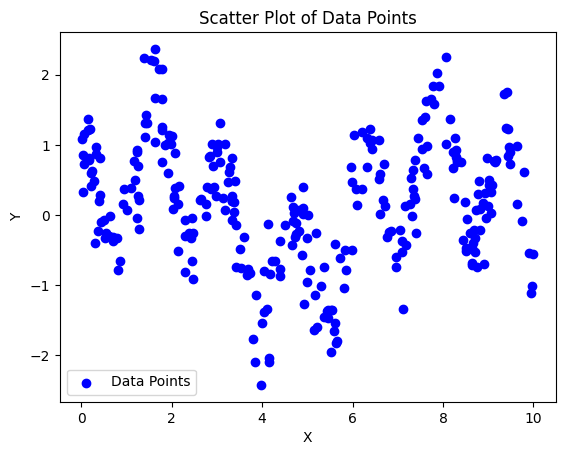

In [28]:
## Problem 1.a
plt.scatter(x, y, color='blue', label='Data Points')
plt.xlabel('X'); plt.ylabel('Y')
plt.title('Scatter Plot of Data Points')
plt.legend()


In [33]:
df.sample(n = 10)

,X,Y
79,6.213670,1.188721
2,1.428410,1.418676
29,4.911498,0.097531
187,4.116817,-1.341415
44,8.602758,-0.262004
5,2.995098,0.974179
111,8.809598,-0.208899
144,6.320903,0.677004
28,9.466267,0.963215
252,0.051468,0.320951


In [ ]:
## Problem 1.b
def SGD(x, y, init = {"theta1": 1, "theta2": 1}, epsilon = 0.01, batch_size = 32, max_iter = 1000):
    
    theta1 = init.get("theta1")
    theta2 = init.get("theta2")

    loss = square_error_loss(y, model_fn(x, theta1, theta2))

    n_sample = len(x)
    iters = 0
    loss_history = []
    while loss > 1e-02 and iters < max_iter:
        m = batch_size
        indices = np.random.choice(n_sample, size=m, replace=False)
        x_batch = x[indices]
        y_batch = y[indices]

        y_pred = model_fn(x_batch, theta1, theta2)
        error = y_batch - y_pred
        
        dtheta1 = np.sin(x_batch)  + np.cos(theta2 * x_batch)
        g1 = (-2 / m) * np.sum(error * dtheta1)
        
        dtheta2 = theta1 * x_batch * np.sin(theta2 * x_batch)
        g2 = ( 2 / m) * np.sum(error * dtheta2)
        theta1 = theta1 - epsilon * g1
        theta2 = theta2 - epsilon * g2
        loss = square_error_loss(y, model_fn(x, theta1, theta2))
        iters += 1
        # print(f"Iteration {iters}: Loss = {loss:.4f}, theta1 = {theta1:.4f}, theta2 = {theta2:.4f}")
        loss_history.append(loss)  
    theta = {"theta1": theta1, "theta2": theta2}
    print(f"SGD finished  in {iters} iterations with loss: {loss:.4f}")
    return loss, theta, loss_history

In [ ]:
loss, theta, loss_history = SGD(x, y, init = {"theta1": 1, "theta2": 1}, epsilon = 0.05, batch_size = 32, max_iter=100000)

SGD finished  in 100000 iterations with loss: 203.3412


In [ ]:
## Problem 1.c
def SGD_momentum(x, y, init = {"theta1": 1, "theta2": 1}, alpha = .9, epsilon = 0.01, batch_size = 32, max_iter = 1000):
    
    theta1 = init.get("theta1")
    theta2 = init.get("theta2")

    loss = square_error_loss(y, model_fn(x, theta1, theta2))

    n_sample = len(x)
    iters = 0
    loss_history = []
    v1, v2 = 0, 0
    while loss > 1e-02 and iters < max_iter:
        m = batch_size
        indices = np.random.choice(n_sample, size=m, replace=False)
        x_batch = x[indices]
        y_batch = y[indices]

        y_pred = model_fn(x_batch, theta1, theta2)
        error = y_batch - y_pred
        
        dtheta1 = np.sin(x_batch)  + np.cos(theta2 * x_batch)
        g1 = (-2 / m) * np.sum(error * dtheta1)

        dtheta2 = theta1 * x_batch * np.sin(theta2 * x_batch)
        g2 = ( 2 / m) * np.sum(error * dtheta2)

        v1 = alpha * v1 - epsilon * g1
        v2 = alpha * v2 - epsilon * g2

        theta1 = theta1 + v1
        theta2 = theta2 + v2
        loss = square_error_loss(y, model_fn(x, theta1, theta2))
        iters += 1
        # print(f"Iteration {iters}: Loss = {loss:.4f}, theta1 = {theta1:.4f}, theta2 = {theta2:.4f}")
        ## save every loss_historys
        loss_history.append(loss)
    theta = {"theta1": theta1, "theta2": theta2}
    print(f"SGD momentum finished in {iters} iterations with loss: {loss:.4f}")
    return loss, theta, loss_history

In [ ]:
loss_m, theta_m, loss_history_m = SGD_momentum(x, y, init = {"theta1": 1, "theta2": 1}, alpha = 0.5, epsilon = 0.05, batch_size = 32, max_iter = 100000)

SGD finished in 100000 iterations with loss: 174.4147


In [ ]:
## test data for both
def test():
    test_x, test_y = generate_hw1_problem1_synth(n=200, theta1_true=1.5, theta2_true=2.0, noise_std=0.2, seed=123)
    loss_sgd, theta_sgd, loss_history_sgd = SGD(test_x, test_y, init = {"theta1": 1.4, "theta2": 1.8}, epsilon = 0.001, batch_size = 32, max_iter=100)
    loss_momentum, theta_momentum, loss_history_momentum = SGD_momentum(test_x, test_y, init = {"theta1": 1.4, "theta2": 1.8}, alpha = 0.5, epsilon = 0.001, batch_size = 32, max_iter = 100)
    plt.figure(figsize=(12, 6))
    plt.plot(loss_history_sgd, label='SGD Loss')
    plt.plot(loss_history_momentum, label='SGD Momentum Loss')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.legend()

In [190]:
## real data for both
loss_sgd, theta_sgd, loss_history_sgd = SGD(x, y, init = {"theta1": 1.4, "theta2": 1.8}, epsilon = 0.001, batch_size = 8, max_iter=50000)
loss_momentum, theta_momentum, loss_history_momentum = SGD_momentum(x, y, init = {"theta1": 1.4, "theta2": 1.8}, alpha = 0.5, epsilon = 0.001, batch_size = 8, max_iter = 5000)

SGD finished  in 50000 iterations with loss: 203.2431
SGD finished in 5000 iterations with loss: 203.4309


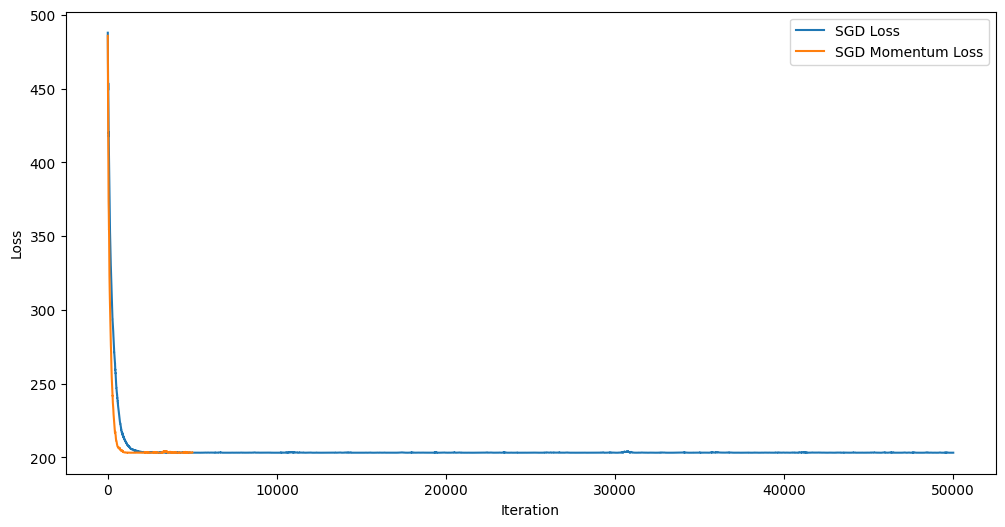

In [191]:
plt.figure(figsize=(12, 6))
plt.plot(loss_history_sgd, label='SGD Loss')
plt.plot(loss_history_momentum, label='SGD Momentum Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()


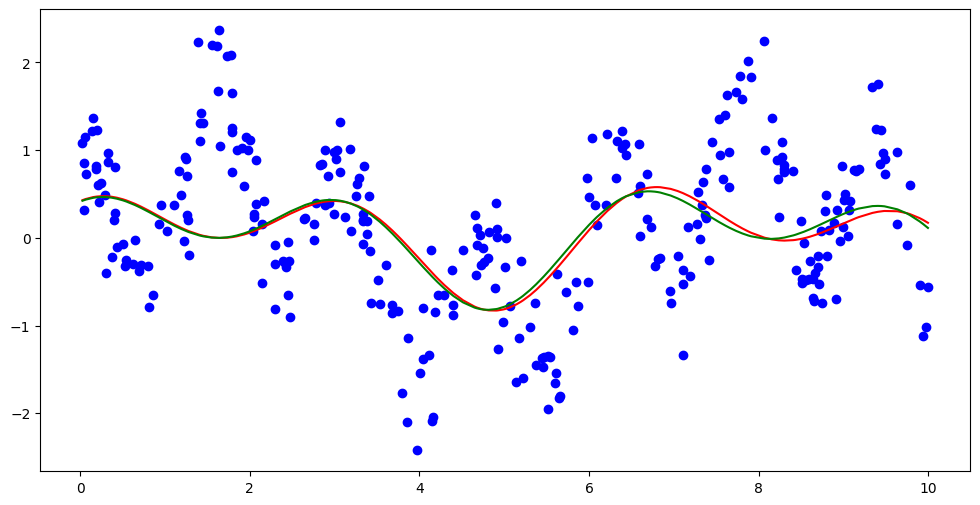

In [192]:
## fit curve
idx = np.argsort(x)
x_sorted = x[idx]
yhat_sgd = model_fn(x_sorted, theta_sgd["theta1"], theta_sgd["theta2"])
yhat_momentum = model_fn(x_sorted, theta_momentum["theta1"], theta_momentum["theta2"])
plt.figure(figsize=(12, 6))
plt.scatter(x, y, color='blue', label='Data Points')
plt.plot(x_sorted, yhat_sgd, color='red', label='SGD Fit')
plt.plot(x_sorted, yhat_momentum, color='green', label='SGD Momentum Fit')